In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel(
    "../data/raw/PCOS_data_without_infertility.xlsx",
    sheet_name="Full_new"
)

print("Dataset Shape:", df.shape)
print("\nColumns:\n")
print(df.columns.tolist())

Dataset Shape: (541, 21)

Columns:

['PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'Blood Group', 'Pulse rate(bpm) ', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'Hip(inch)', 'Waist(inch)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'Sleep Duration (hr)']


In [ ]:
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

1. PCOS (Y/N)
2.  Age (yrs)
3. Weight (Kg)
4. Height(Cm) 
5. Blood Group
6. Pulse rate(bpm) 
7. Cycle(R/I)
8. Cycle length(days)
9. Marraige Status (Yrs)
10. Pregnant(Y/N)
11. No. of aborptions
12. Hip(inch)
13. Waist(inch)
14. Weight gain(Y/N)
15. hair growth(Y/N)
16. Skin darkening (Y/N)
17. Hair loss(Y/N)
18. Pimples(Y/N)
19. Fast food (Y/N)
20. Reg.Exercise(Y/N)
21. Sleep Duration (hr)


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df['PCOS (Y/N)'].value_counts())


Missing Values:
PCOS (Y/N)               0
 Age (yrs)               0
Weight (Kg)              0
Height(Cm)               0
Blood Group              0
Pulse rate(bpm)          0
Cycle(R/I)               0
Cycle length(days)       0
Marraige Status (Yrs)    1
Pregnant(Y/N)            0
No. of aborptions        0
Hip(inch)                0
Waist(inch)              0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
Hair loss(Y/N)           0
Pimples(Y/N)             0
Fast food (Y/N)          1
Reg.Exercise(Y/N)        0
Sleep Duration (hr)      0
dtype: int64

Duplicate Rows:
0

Target Distribution:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Handle Missing Values

df["Marraige Status (Yrs)"] = (
    df["Marraige Status (Yrs)"]
    .fillna(df["Marraige Status (Yrs)"].median())
)

df["Fast food (Y/N)"] = (
    df["Fast food (Y/N)"]
    .fillna(df["Fast food (Y/N)"].mode()[0])
)

print(df.isnull().sum())

PCOS (Y/N)               0
 Age (yrs)               0
Weight (Kg)              0
Height(Cm)               0
Blood Group              0
Pulse rate(bpm)          0
Cycle(R/I)               0
Cycle length(days)       0
Marraige Status (Yrs)    0
Pregnant(Y/N)            0
No. of aborptions        0
Hip(inch)                0
Waist(inch)              0
Weight gain(Y/N)         0
hair growth(Y/N)         0
Skin darkening (Y/N)     0
Hair loss(Y/N)           0
Pimples(Y/N)             0
Fast food (Y/N)          0
Reg.Exercise(Y/N)        0
Sleep Duration (hr)      0
dtype: int64


In [ ]:
for col in df.columns:
    print(repr(col))

'PCOS (Y/N)'
' Age (yrs)'
'Weight (Kg)'
'Height(Cm) '
'Blood Group'
'Pulse rate(bpm) '
'Cycle(R/I)'
'Cycle length(days)'
'Marraige Status (Yrs)'
'Pregnant(Y/N)'
'No. of aborptions'
'Hip(inch)'
'Waist(inch)'
'Weight gain(Y/N)'
'hair growth(Y/N)'
'Skin darkening (Y/N)'
'Hair loss(Y/N)'
'Pimples(Y/N)'
'Fast food (Y/N)'
'Reg.Exercise(Y/N)'
'Sleep Duration (hr)'


In [ ]:
# Remove leading and trailing spaces from all column names
df.columns = df.columns.str.strip()

for col in df.columns:
    print(repr(col))
    

'PCOS (Y/N)'
'Age (yrs)'
'Weight (Kg)'
'Height(Cm)'
'Blood Group'
'Pulse rate(bpm)'
'Cycle(R/I)'
'Cycle length(days)'
'Marraige Status (Yrs)'
'Pregnant(Y/N)'
'No. of aborptions'
'Hip(inch)'
'Waist(inch)'
'Weight gain(Y/N)'
'hair growth(Y/N)'
'Skin darkening (Y/N)'
'Hair loss(Y/N)'
'Pimples(Y/N)'
'Fast food (Y/N)'
'Reg.Exercise(Y/N)'
'Sleep Duration (hr)'


In [ ]:
# Feature Engineering

df["BMI"] = (
    df["Weight (Kg)"] /
    ((df["Height(Cm)"] / 100) ** 2)
)

df["Waist_Hip_Ratio"] = (
    df["Waist(inch)"] /
    df["Hip(inch)"]
)

print(df[["BMI", "Waist_Hip_Ratio"]].head())


         BMI  Waist_Hip_Ratio
0  19.304017         0.833333
1  24.921163         0.842105
2  25.270891         0.900000
3  29.674945         0.857143
4  20.060954         0.810811


In [ ]:
print(df.shape)


(541, 23)


In [ ]:
# Save cleaned dataset

df.to_csv(
    "../data/processed/cleaned_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
# Features and Target

X = df.drop("PCOS (Y/N)", axis=1)
y = df["PCOS (Y/N)"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (541, 22)
Target Shape: (541,)


In [ ]:
# Categorical and Numerical Features

categorical_features = [
    "Blood Group",
    "Cycle(R/I)",
    "Pregnant(Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"
]

numerical_features = [
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "Pulse rate(bpm)",
    "Cycle length(days)",
    "Marraige Status (Yrs)",
    "No. of abortions",
    "Hip(inch)",
    "Waist(inch)",
    "Sleep Duration (hr)",
    "BMI",
    "Waist_Hip_Ratio"
]

print("Categorical:", len(categorical_features))
print("Numerical:", len(numerical_features))

Categorical: 10
Numerical: 12


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Set: (432, 22)
Testing Set: (109, 22)

Training Target Distribution:
PCOS (Y/N)
0    291
1    141
Name: count, dtype: int64

Testing Target Distribution:
PCOS (Y/N)
0    73
1    36
Name: count, dtype: int64


In [ ]:
for col in X.columns:
    print(repr(col))

'Age (yrs)'
'Weight (Kg)'
'Height(Cm)'
'Blood Group'
'Pulse rate(bpm)'
'Cycle(R/I)'
'Cycle length(days)'
'Marraige Status (Yrs)'
'Pregnant(Y/N)'
'No. of aborptions'
'Hip(inch)'
'Waist(inch)'
'Weight gain(Y/N)'
'hair growth(Y/N)'
'Skin darkening (Y/N)'
'Hair loss(Y/N)'
'Pimples(Y/N)'
'Fast food (Y/N)'
'Reg.Exercise(Y/N)'
'Sleep Duration (hr)'
'BMI'
'Waist_Hip_Ratio'


In [ ]:
missing_cols = []

for col in numerical_features + categorical_features:
    if col not in X.columns:
        missing_cols.append(col)

print(missing_cols)

['No. of abortions']


In [ ]:
for col in X.columns:
    if "abort" in col.lower():
        print(repr(col))

In [ ]:
set(numerical_features) - set(X.columns)


{'No. of abortions'}

In [ ]:
set(X.columns) - set(numerical_features) - set(categorical_features)

{'No. of aborptions'}

In [ ]:
numerical_features = [
    "Age (yrs)",
    "Weight (Kg)",
    "Height(Cm)",
    "Pulse rate(bpm)",
    "Cycle length(days)",
    "Marraige Status (Yrs)",
    X.columns[9],   # abortion column directly from dataframe
    "Hip(inch)",
    "Waist(inch)",
    "Sleep Duration (hr)",
    "BMI",
    "Waist_Hip_Ratio"
]

In [ ]:
print(repr(X.columns[9]))

'No. of aborptions'


In [ ]:
print(numerical_features)

['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'Pulse rate(bpm)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'No. of aborptions', 'Hip(inch)', 'Waist(inch)', 'Sleep Duration (hr)', 'BMI', 'Waist_Hip_Ratio']


In [ ]:
print("Missing Numerical:")
print(set(numerical_features) - set(X.columns))

print("\nMissing Categorical:")
print(set(categorical_features) - set(X.columns))

Missing Numerical:
set()

Missing Categorical:
set()


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

print("Success!")
print(X_train_processed.shape)

Success!
(432, 39)


In [ ]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nNew Shape:")
print(X_train_smote.shape)

Before SMOTE:
PCOS (Y/N)
0    291
1    141
Name: count, dtype: int64

After SMOTE:
PCOS (Y/N)
0    291
1    291
Name: count, dtype: int64

New Shape:
(582, 39)


In [ ]:
from imblearn.over_sampling import SMOTE

# Preprocess data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Shapes:")
print(X_train_processed.shape)
print(X_test_processed.shape)

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nSMOTE Shape:")
print(X_train_smote.shape)

Processed Shapes:
(432, 39)
(109, 39)

Before SMOTE:
PCOS (Y/N)
0    291
1    141
Name: count, dtype: int64

After SMOTE:
PCOS (Y/N)
0    291
1    291
Name: count, dtype: int64

SMOTE Shape:
(582, 39)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_lr = lr_model.predict(X_test_processed)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

Logistic Regression Accuracy: 0.981651376146789


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Confusion Matrix:

[[71  2]
 [ 0 36]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        73
           1       0.95      1.00      0.97        36

    accuracy                           0.98       109
   macro avg       0.97      0.99      0.98       109
weighted avg       0.98      0.98      0.98       109



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_dt = dt_model.predict(
    X_test_processed
)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, y_pred_dt)
)

Decision Tree Accuracy: 0.981651376146789


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf = rf_model.predict(
    X_test_processed
)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Random Forest Accuracy: 0.963302752293578


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_svm = svm_model.predict(
    X_test_processed
)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)

SVM Accuracy: 0.9724770642201835


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_xgb = xgb_model.predict(
    X_test_processed
)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, y_pred_xgb)
)

XGBoost Accuracy: 0.9724770642201835


In [ ]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.9817
Decision Tree: 0.9817
Random Forest: 0.9633
SVM: 0.9725
XGBoost: 0.9725


In [ ]:
import joblib

joblib.dump(
    lr_model,
    "../backend/models/pcos_model.pkl"
)

joblib.dump(
    preprocessor,
    "../backend/models/preprocessor.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_names = preprocessor.get_feature_names_out()

importance = np.abs(lr_model.coef_[0])

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                        Feature  Importance
9      num__Sleep Duration (hr)    4.496771
29  cat__Skin darkening (Y/N)_0    0.943627
30  cat__Skin darkening (Y/N)_1    0.942524
27      cat__hair growth(Y/N)_0    0.761476
28      cat__hair growth(Y/N)_1    0.760373
20            cat__Cycle(R/I)_2    0.644367
21            cat__Cycle(R/I)_4    0.643652
14          cat__Blood Group_13    0.596511
35     cat__Fast food (Y/N)_0.0    0.567085
36     cat__Fast food (Y/N)_1.0    0.565981
18          cat__Blood Group_17    0.502749
16          cat__Blood Group_15    0.415840
2               num__Height(Cm)    0.380162
15          cat__Blood Group_14    0.289673
25      cat__Weight gain(Y/N)_0    0.285715


In [ ]:
df.groupby("PCOS (Y/N)")["Sleep Duration (hr)"].describe()

,count,mean,std,min,25%,50%,75%,max
PCOS (Y/N),,,,,,,,
0,364.0,8.120879,1.172083,4.0,7.0,8.0,9.0,12.0
1,177.0,4.514124,0.769499,2.0,4.0,4.0,5.0,8.0


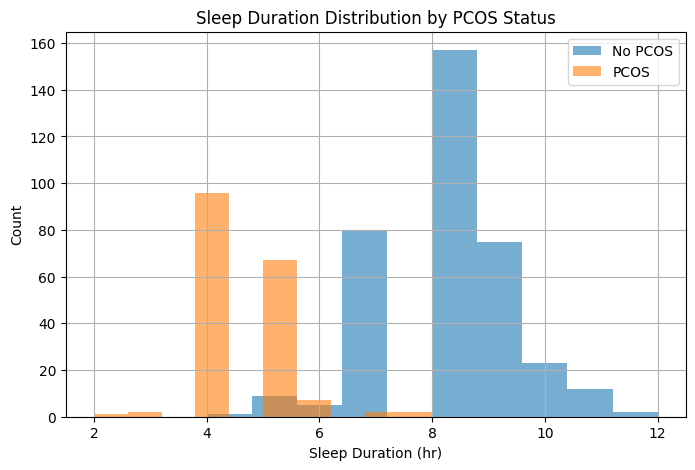

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df[df["PCOS (Y/N)"] == 0]["Sleep Duration (hr)"].hist(
    alpha=0.6,
    label="No PCOS"
)

df[df["PCOS (Y/N)"] == 1]["Sleep Duration (hr)"].hist(
    alpha=0.6,
    label="PCOS"
)

plt.xlabel("Sleep Duration (hr)")
plt.ylabel("Count")
plt.title("Sleep Duration Distribution by PCOS Status")
plt.legend()

plt.show()

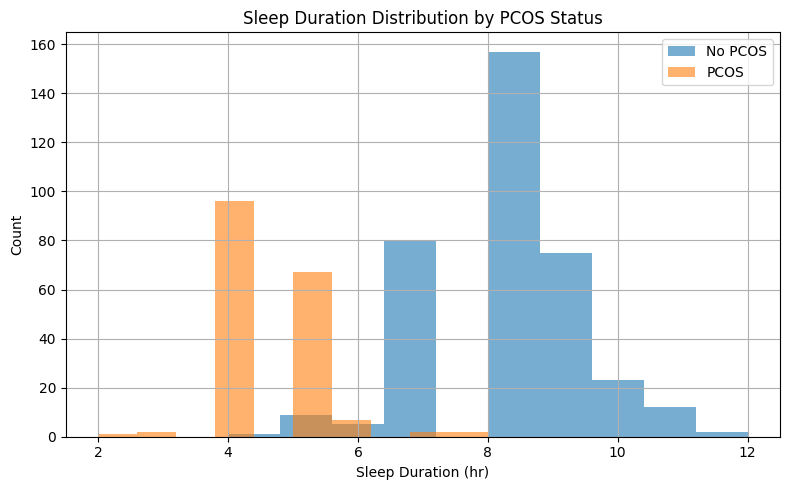

In [ ]:
plt.figure(figsize=(8,5))

df[df["PCOS (Y/N)"] == 0]["Sleep Duration (hr)"].hist(
    alpha=0.6,
    label="No PCOS"
)

df[df["PCOS (Y/N)"] == 1]["Sleep Duration (hr)"].hist(
    alpha=0.6,
    label="PCOS"
)

plt.xlabel("Sleep Duration (hr)")
plt.ylabel("Count")
plt.title("Sleep Duration Distribution by PCOS Status")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../backend/results/sleep_duration_distribution.png",
    dpi=300
)

plt.show()

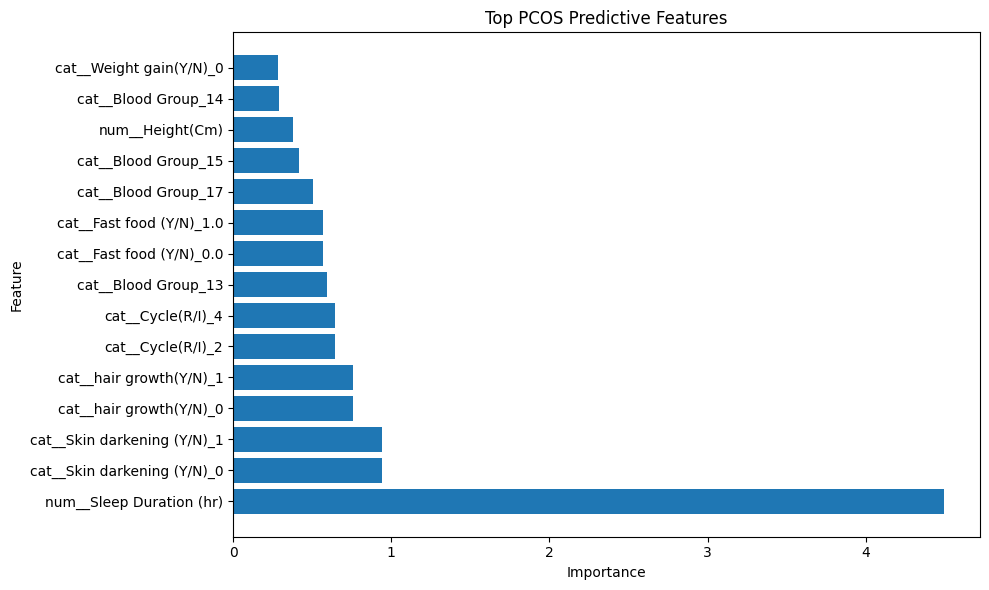

In [ ]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top PCOS Predictive Features")

plt.tight_layout()
plt.show()

In [ ]:
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

print(importance_df.head())

                   Feature  Importance
9      Sleep Duration (hr)    4.496771
29  Skin darkening (Y/N)_0    0.943627
30  Skin darkening (Y/N)_1    0.942524
27      hair growth(Y/N)_0    0.761476
28      hair growth(Y/N)_1    0.760373


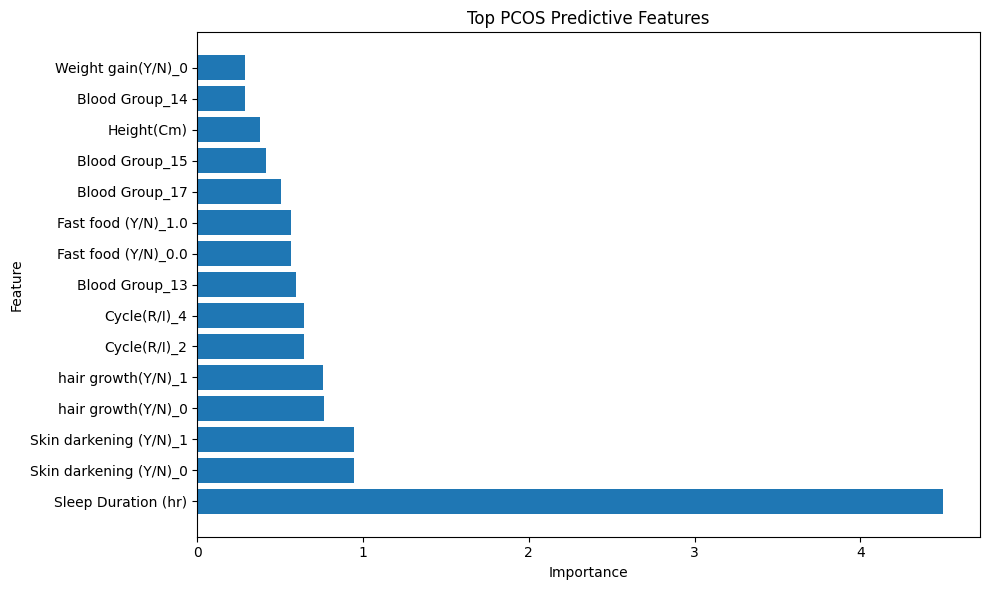

In [ ]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top PCOS Predictive Features")

plt.tight_layout()
plt.show()

In [ ]:
clinical_importance = (
    importance_df
    .assign(
        Feature=importance_df["Feature"]
        .str.replace(r"_\d+$", "", regex=True)
    )
    .groupby("Feature")["Importance"]
    .sum()
    .reset_index()
)

clinical_importance = clinical_importance.sort_values(
    by="Importance",
    ascending=False
)

print(clinical_importance.head(10))

                 Feature  Importance
17   Sleep Duration (hr)    4.496771
2            Blood Group    2.475367
16  Skin darkening (Y/N)    1.886151
22      hair growth(Y/N)    1.521849
4             Cycle(R/I)    1.288408
21      Weight gain(Y/N)    0.570327
5    Fast food (Y/N)_0.0    0.567085
6    Fast food (Y/N)_1.0    0.565981
13         Pregnant(Y/N)    0.542186
8             Height(Cm)    0.380162


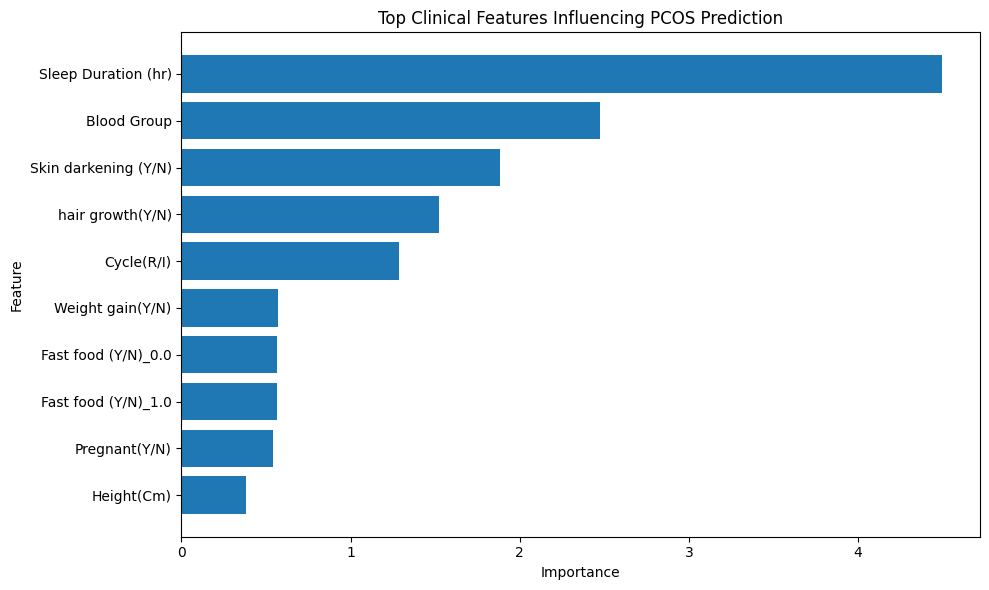

In [ ]:
plt.figure(figsize=(10,6))

top = clinical_importance.head(10)

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Clinical Features Influencing PCOS Prediction")

plt.tight_layout()

plt.show()

In [ ]:
# PCOD Score

df["PCOD_Score"] = 0

# Irregular Cycle
df.loc[df["Cycle(R/I)"] != "R", "PCOD_Score"] += 2

# Weight Gain
df.loc[df["Weight gain(Y/N)"] == "Y", "PCOD_Score"] += 1

# Pimples
df.loc[df["Pimples(Y/N)"] == "Y", "PCOD_Score"] += 1

# Hair Loss
df.loc[df["Hair loss(Y/N)"] == "Y", "PCOD_Score"] += 1

# Fast Food
df.loc[df["Fast food (Y/N)"] == "Y", "PCOD_Score"] += 1

# No Exercise
df.loc[df["Reg.Exercise(Y/N)"] == "N", "PCOD_Score"] += 1

# BMI
df.loc[df["BMI"] > 25, "PCOD_Score"] += 2

In [ ]:
def assign_condition(row):

    # Highest priority
    if row["PCOS (Y/N)"] == 1:
        return "PCOS"

    # Rule-based PCOD
    elif row["PCOD_Score"] >= 4:
        return "PCOD"

    # Healthy
    else:
        return "Normal"

df["Condition"] = df.apply(
    assign_condition,
    axis=1
)

print(df["Condition"].value_counts())

Condition
Normal    231
PCOS      177
PCOD      133
Name: count, dtype: int64


In [ ]:
df.to_csv(
    "../data/processed/pcos_binary_dataset.csv",
    index=False
)

In [ ]:
df["Condition"]

0      Normal
1      Normal
2        PCOS
3        PCOD
4      Normal
        ...  
536    Normal
537      PCOD
538    Normal
539    Normal
540      PCOS
Name: Condition, Length: 541, dtype: str

In [ ]:
df.to_csv(
    "../data/processed/pcod_pcos_multiclass_dataset.csv",
    index=False
)

In [ ]:
df["PCOD_Score"] = 0

# Irregular cycle
df.loc[df["Cycle(R/I)"] != 2, "PCOD_Score"] += 1

# Weight gain
df.loc[df["Weight gain(Y/N)"] == 1, "PCOD_Score"] += 1

# Pimples
df.loc[df["Pimples(Y/N)"] == 1, "PCOD_Score"] += 1

# Hair loss
df.loc[df["Hair loss(Y/N)"] == 1, "PCOD_Score"] += 1

# High BMI
df.loc[df["BMI"] > 25, "PCOD_Score"] += 1

In [ ]:
print(df["Cycle(R/I)"].unique())
print(df["Weight gain(Y/N)"].unique())
print(df["Pimples(Y/N)"].unique())
print(df["Hair loss(Y/N)"].unique())

[2 4 5]
[0 1]
[0 1]
[0 1]


print("Cycle(R/I):")
print(df["Cycle(R/I)"].value_counts())

print("\nWeight gain(Y/N):")
print(df["Weight gain(Y/N)"].value_counts())

print("\nHair loss(Y/N):")
print(df["Hair loss(Y/N)"].value_counts())

print("\nPimples(Y/N):")
print(df["Pimples(Y/N)"].value_counts())

In [ ]:
print("Cycle(R/I):")
print(df["Cycle(R/I)"].value_counts())

print("\nWeight gain(Y/N):")
print(df["Weight gain(Y/N)"].value_counts())

print("\nHair loss(Y/N):")
print(df["Hair loss(Y/N)"].value_counts())

print("\nPimples(Y/N):")
print(df["Pimples(Y/N)"].value_counts())

Cycle(R/I):
Cycle(R/I)
2    390
4    150
5      1
Name: count, dtype: int64

Weight gain(Y/N):
Weight gain(Y/N)
0    337
1    204
Name: count, dtype: int64

Hair loss(Y/N):
Hair loss(Y/N)
0    296
1    245
Name: count, dtype: int64

Pimples(Y/N):
Pimples(Y/N)
0    276
1    265
Name: count, dtype: int64


In [ ]:
# Create PCOD Score

df["PCOD_Score"] = 0

# Irregular Cycle
df.loc[df["Cycle(R/I)"] != 2, "PCOD_Score"] += 1

# Weight Gain
df.loc[df["Weight gain(Y/N)"] == 1, "PCOD_Score"] += 1

# Hair Loss
df.loc[df["Hair loss(Y/N)"] == 1, "PCOD_Score"] += 1

# Pimples
df.loc[df["Pimples(Y/N)"] == 1, "PCOD_Score"] += 1

# High BMI
df.loc[df["BMI"] > 25, "PCOD_Score"] += 1

In [ ]:
df["PCOD_Score"].value_counts().sort_index()

PCOD_Score
0     93
1    118
2    152
3     79
4     63
5     36
Name: count, dtype: int64

In [ ]:
df["PCOD_Score"].describe()

count    541.000000
mean       2.016636
std        1.456054
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: PCOD_Score, dtype: float64

In [ ]:
df["PCOD_Score"].value_counts().sort_index()

PCOD_Score
0     93
1    118
2    152
3     79
4     63
5     36
Name: count, dtype: int64

In [ ]:
df["PCOD"] = 0

df.loc[df["PCOD_Score"] >= 4, "PCOD"] = 1

print(df["PCOD"].value_counts())

PCOD
0    442
1     99
Name: count, dtype: int64


In [ ]:
def assign_condition(row):

    if row["PCOS (Y/N)"] == 1:
        return "PCOS"

    elif row["PCOD"] == 1:
        return "PCOD"

    else:
        return "Normal"

df["Condition"] = df.apply(
    assign_condition,
    axis=1
)

print(df["Condition"].value_counts())

Condition
Normal    341
PCOS      177
PCOD       23
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Condition_Label"] = le.fit_transform(
    df["Condition"]
)

print(le.classes_)

['Normal' 'PCOD' 'PCOS']


In [ ]:
print(df["Condition_Label"].value_counts())

Condition_Label
0    341
2    177
1     23
Name: count, dtype: int64


In [ ]:
df.to_csv(
    "../data/processed/pcod_pcos_multiclass_dataset.csv",
    index=False
)

In [ ]:
df.to_csv(
    "../data/processed/pcod_pcos_multiclass_dataset.csv",
    index=False
)

In [ ]:
X = df.drop(
    columns=[
        "PCOS (Y/N)",
        "PCOD",
        "PCOD_Score",
        "Condition",
        "Condition_Label"
    ]
)

y = df["Condition_Label"]

print(X.shape)
print(y.value_counts())

(541, 22)
Condition_Label
0    341
2    177
1     23
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(432, 22)
(109, 22)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(432, 39)
(109, 39)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_multi = LogisticRegression(
    max_iter=1000
)

lr_multi.fit(
    X_train_processed,
    y_train
)

y_pred_lr = lr_multi.predict(
    X_test_processed
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Normal", "PCOD", "PCOS"]
    )
)

Accuracy: 0.963302752293578

Confusion Matrix:
[[67  0  2]
 [ 1  2  1]
 [ 0  0 36]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98        69
        PCOD       1.00      0.50      0.67         4
        PCOS       0.92      1.00      0.96        36

    accuracy                           0.96       109
   macro avg       0.97      0.82      0.87       109
weighted avg       0.97      0.96      0.96       109



In [ ]:
# RANDOM FOREST 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_multi = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_multi.fit(
    X_train_processed,
    y_train
)

y_pred_rf = rf_multi.predict(
    X_test_processed
)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Random Forest Accuracy: 0.944954128440367


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Normal","PCOD","PCOS"]
    )
)

              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96        69
        PCOD       1.00      0.75      0.86         4
        PCOS       0.88      0.97      0.92        36

    accuracy                           0.94       109
   macro avg       0.95      0.89      0.91       109
weighted avg       0.95      0.94      0.95       109



In [ ]:
#XGBoost Multiclass
from xgboost import XGBClassifier

xgb_multi = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_multi.fit(
    X_train_processed,
    y_train
)

y_pred_xgb = xgb_multi.predict(
    X_test_processed
)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, y_pred_xgb)
)

XGBoost Accuracy: 0.9541284403669725


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Normal","PCOD","PCOS"]
    )
)

              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97        69
        PCOD       1.00      0.75      0.86         4
        PCOS       0.88      1.00      0.94        36

    accuracy                           0.95       109
   macro avg       0.96      0.90      0.92       109
weighted avg       0.96      0.95      0.95       109



In [ ]:
results = {
    "Logistic Regression":
        accuracy_score(y_test, y_pred_lr),

    "Random Forest":
        accuracy_score(y_test, y_pred_rf),

    "XGBoost":
        accuracy_score(y_test, y_pred_xgb)
}

for model, score in results.items():
    print(
        f"{model}: {score:.4f}"
    )

Logistic Regression: 0.9633
Random Forest: 0.9450
XGBoost: 0.9541


In [ ]:
import joblib

joblib.dump(
    xgb_multi,
    "../backend/models/pcod_pcos_model.pkl"
)

joblib.dump(
    preprocessor,
    "../backend/models/preprocessor.pkl"
)

joblib.dump(
    le,
    "../backend/models/label_encoder.pkl"
)

print("Models saved successfully!")

Models saved successfully!


In [ ]:
import os

print(os.listdir("../backend/models"))

['label_encoder.pkl', 'pcod_pcos_model.pkl', 'pcos_model.pkl', 'preprocessor.pkl']


In [ ]:
import joblib

le = joblib.load("../backend/models/label_encoder.pkl")
print(le.classes_)

['Normal' 'PCOD' 'PCOS']


In [1]:
import joblib

preprocessor = joblib.load(
    "../backend/models/preprocessor.pkl"
)

for col in preprocessor.feature_names_in_:
    print(col)

Age (yrs)
Weight (Kg)
Height(Cm)
Blood Group
Pulse rate(bpm)
Cycle(R/I)
Cycle length(days)
Marraige Status (Yrs)
Pregnant(Y/N)
No. of aborptions
Hip(inch)
Waist(inch)
Weight gain(Y/N)
hair growth(Y/N)
Skin darkening (Y/N)
Hair loss(Y/N)
Pimples(Y/N)
Fast food (Y/N)
Reg.Exercise(Y/N)
Sleep Duration (hr)
BMI
Waist_Hip_Ratio


In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_dataset.csv")

print(df.columns.tolist())

['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'Blood Group', 'Pulse rate(bpm)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'Hip(inch)', 'Waist(inch)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'Sleep Duration (hr)', 'BMI', 'Waist_Hip_Ratio']


In [5]:
import joblib

preprocessor = joblib.load("../backend/models/preprocessor.pkl")

for col in preprocessor.feature_names_in_:
    print(col)
    

Age (yrs)
Weight (Kg)
Height(Cm)
Blood Group
Pulse rate(bpm)
Cycle(R/I)
Cycle length(days)
Marraige Status (Yrs)
Pregnant(Y/N)
No. of aborptions
Hip(inch)
Waist(inch)
Weight gain(Y/N)
hair growth(Y/N)
Skin darkening (Y/N)
Hair loss(Y/N)
Pimples(Y/N)
Fast food (Y/N)
Reg.Exercise(Y/N)
Sleep Duration (hr)
BMI
Waist_Hip_Ratio


In [6]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_dataset.csv")

df.drop(columns=["Blood Group"], inplace=True)

df.rename(columns={
    "Cycle(R/I)": "Cycle (Irregularity)",
    "Marraige Status (Yrs)": "Marriage Status (Yrs)",
    "No. of aborptions": "No. of abortions"
}, inplace=True)

df.to_csv(
    "../data/processed/cleaned_dataset.csv",
    index=False
)

print(df.columns.tolist())

['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'Pulse rate(bpm)', 'Cycle (Irregularity)', 'Cycle length(days)', 'Marriage Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions', 'Hip(inch)', 'Waist(inch)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'Sleep Duration (hr)', 'BMI', 'Waist_Hip_Ratio']


In [7]:
df = pd.read_csv(...)

ValueError: Invalid file path or buffer object type: <class 'ellipsis'>